# 4. Fewer, broader labels

HECTOR chooses from 1,407 cell types, and on a real dataset it will use far
more of them than you want to look at. This tutorial replaces those labels with
a smaller set of broader ones, using `hector.simplify_ontology_tree`.

The point is not to hide detail. It is that some questions are asked at a
coarser grain than the answer HECTOR gives. "How many bipolar cells are there?"
is a reasonable question, and a table listing twelve kinds of bipolar cell
separately does not answer it. A figure legend with sixty entries has the same
problem.

One call does the whole thing: it works out which types belong together, writes
a new label per cell, and leaves the original labels untouched so you can go
back.

## Getting the data

This tutorial uses the same developing human retina as tutorial 03 — about
226,000 cell nuclei from 14 donors, sampled from week 9 to week 24 after
fertilisation. A retina contains many closely related cell types, which is what
makes it worth simplifying.

> Zuo Z, Cheng X, Ferdous S, *et al.* "Single cell dual-omic atlas of the human
> developing retina." *Nat Commun* **15**, 6792 (2024).
> doi:[10.1038/s41467-024-50853-5](https://doi.org/10.1038/s41467-024-50853-5)

**The download is 3.1 GB.** If you ran tutorial 03 in this directory the file is
already here and the cell below does nothing. The tutorials do not otherwise
depend on each other.

In [1]:
import pathlib
import shutil
import urllib.request

URL = ("https://datasets.cellxgene.cziscience.com/"
       "883270e9-41e6-4c2c-b352-b15c292d2a34.h5ad")
SOURCE = pathlib.Path("retina_fetal.h5ad")

if not SOURCE.exists():
    with urllib.request.urlopen(URL) as response, open(SOURCE, "wb") as handle:
        shutil.copyfileobj(response, handle)

## Step 1. Take a slice and get back to raw counts

Two things worth repeating from tutorial 03. `backed="r"` opens the file with
the expression matrix left on disk, so a 3.1 GB file does not have to fit in
memory. And files from CELLxGENE store normalised values in `.X`, keeping the
original counts in `.raw` — **HECTOR needs the raw counts**, so the matrix you
get by default is the wrong one.

The same 25,000 nuclei as tutorial 03, drawn with the same seed.

In [2]:
import anndata as ad
import numpy as np

full = ad.read_h5ad(SOURCE, backed="r")

rng = np.random.default_rng(0)
chosen = np.sort(rng.choice(full.n_obs, 25_000, replace=False))
adata = full[chosen].to_memory()
full.file.close()

adata = adata.raw.to_adata()
adata.shape

(25000, 35469)

## Step 2. Annotate the cells

The same three lines as every tutorial so far. If you already have an annotated
`.h5ad` file, load it and skip this step.

In [3]:
import hector

predictor = hector.HECTOR("human")
predictions = predictor.predict(adata, label_format="name")
predictor.write_predictions(adata, predictions)

adata.obs["hector_prediction"].nunique()

<environment>/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  ☑️  MLX encoder loaded
  ☑️  MLX CellTypeEmbedder loaded
  ☑️  MLX HPLHead loaded


  📂 Loaded Memory Bank: 100,000 anchor cells
 🎉 Model loaded successfully! 🥳
   Prediction hardware: GPU (Apple M1 Max, MLX)
   Supported cell types: 1407
  [INFO] Making predictions on 25000 cells...
  Settings: top_k=1, use_grit=True, zero_shot=True
  Step 0: Checking gene IDs...


  Step 1: Gene Matching and Reordering ...


  Gene matching: 4983/5000 (99.7% of reference genes found)
  Step 2: Processing expression data...


...

  kNN graph:  50%|███████████████               | 2/4 [00:01<00:01,  1.93tile/s]

  kNN graph:  75%|██████████████████████▌       | 3/4 [00:01<00:00,  2.69tile/s]

  kNN graph: 100%|██████████████████████████████| 4/4 [00:01<00:00,  3.03tile/s]

  ✅ Predictions complete!
  Step 5: Formatting results...
  ✅ Results formatted as DataFrame with shape (25000, 3)
  Rare-cell rollup summary: threshold=20 cells (min(1.0% of 25000, 20)), 36 type(s) bucketed as 'Rare Cells', 96 cell(s) affected
  Annotated adata.obs with 5 columns (prefix='hector_', 25000/25000 cells matched)


63

## Step 3. The problem

Sixty-three distinct labels across 25,000 nuclei. The count on its own is not
the problem — the problem is what the long tail is made of. Look at every label
containing the word *bipolar*:

In [4]:
counts = adata.obs["hector_prediction"].value_counts()
counts[counts.index.str.contains("bipolar")]

hector_prediction
flat midget bipolar cell                469
retinal bipolar neuron                  397
diffuse bipolar 3b cell                 357
diffuse bipolar 2 cell                  247
diffuse bipolar 1 cell                  188
invaginating midget bipolar cell        183
diffuse bipolar 3a cell                 156
rod bipolar cell                        139
ON-bipolar cell                          86
diffuse bipolar 6 cell                   54
diffuse bipolar 4 cell                   44
OFF-bipolar cell                         18
type 3 cone bipolar cell (sensu Mus)      6
diffuse bipolar 5 cell                    3
giant bipolar cell                        1
ON-blue cone bipolar cell                 1
Name: count, dtype: int64

Sixteen labels for one family of cells, splitting 2,349 nuclei sixteen ways.
`diffuse bipolar 1` through `diffuse bipolar 6` are genuine named subtypes of
retinal bipolar neuron and HECTOR is right to distinguish them — but if the
question is how the bipolar population as a whole behaves, these sixteen rows
are sixteen pieces of one answer.

The bottom of that list also shows what a long tail is made of: four labels
hold eleven nuclei between them, and one of them, `type 3 cone bipolar cell
(sensu Mus)`, is a term defined for mouse retina.

Drawing the tree, as tutorial 02 did, shows the same thing as a shape. The
bipolar branch on the lower right splits and splits again:

In [5]:
hector.create_trajectory_analysis(
    predictor=predictor,
    adata=adata,
    output_file="04_before.pdf",
    title="Developing retina — before simplification",
    layout_mode="radial",
    label_format="name",
)

[INFO] Reusing cached predictions from adata.uns['hector_prediction_core_manifest'] (same cells, same settings). Pass force_recompute=True to recompute.

HECTOR Tree Visualization
Unity Mode: GRIT=On
Label Format: name
[INFO] Extracting visualization vectors (Unity Mode: GRIT=On)...
[INFO] Processing 25000 cells...
[INFO] Reusing cached predictions from adata.uns['hector_prediction_core_manifest'] (same cells, same settings). Pass force_recompute=True to recompute.


[INFO] Pruning cell types below 20 cells: 36 cell types removed.


[INFO] Starting Trajectory Analysis...
[INFO] Layout pipeline: Using PURE ontology DAG
Converting DAG to Strict Tree for Radial Layout...


[INFO] Visual pipeline: Building visual edges


[HECTOR] auto-detected stable_source_zone=0.1352, stable_target_zone=0.0229  (mode=auto)


  > Tagged 11909 Transitioning Typical, 13003 Stable Typical, 0 Clustered Atypical, and 0 Unclustered Atypical cells.
  Cells: 24912 | Nodes: 40 | Edges: 39 (inferred paths: 0)
Plot generating......


✅ Saved radial tree: 04_before.pdf


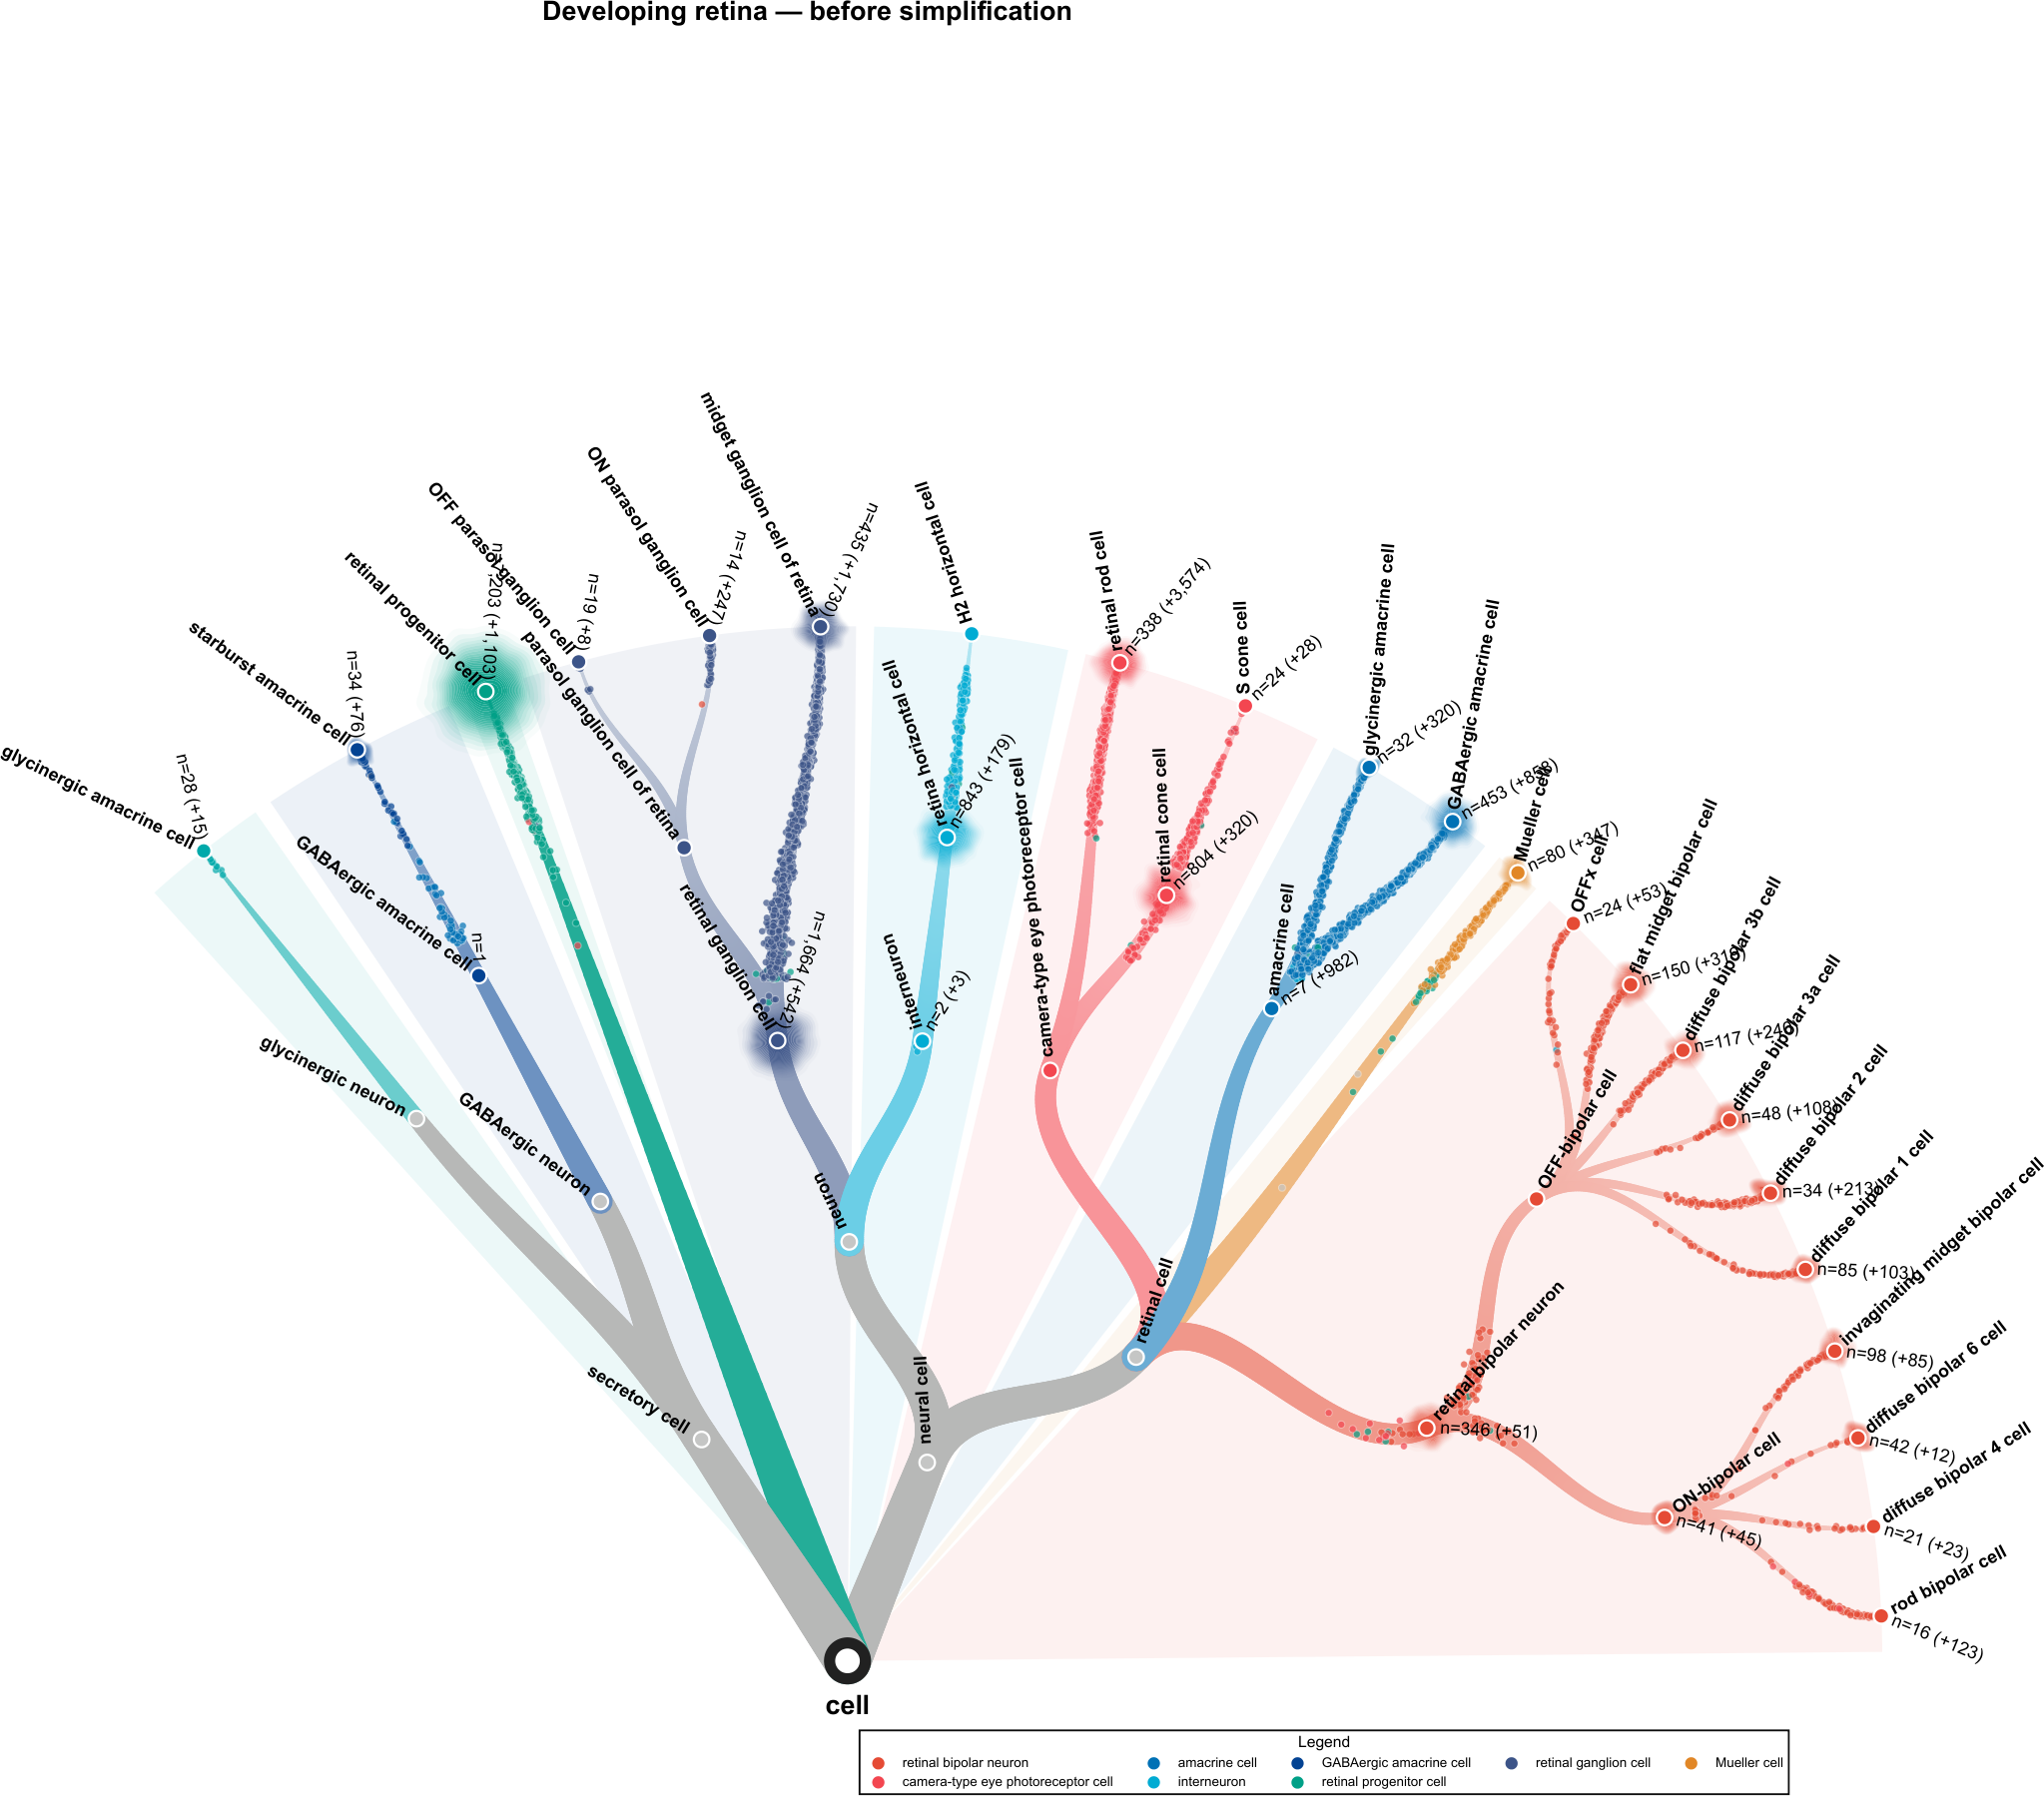

Twenty-seven of the sixty-three types have at least twenty cells and are drawn;
the rest are pruned. The figure carries forty labelled points rather than
twenty-seven because it also draws the ancestors needed to connect them.

Pruning is a separate mechanism from anything else in this tutorial: it removes
types from a *picture*, while simplification changes the *labels*.

## Step 4. One call

`simplify_ontology_tree` walks the cell ontology, decides which of your types
are close enough to be treated as one, and writes the result to
`adata.obs["simplified_prediction"]`. `hector_prediction` is left alone.

The two arguments that matter are `algorithm` and, for this one,
`similarity_threshold`. Step 6 covers the alternatives; start here.

`algorithm="wang"` judges how alike two cell types are by how much of their
ancestry they share, counting a shared ancestor for less the further it sits
above them. Two types with the same parent score high; two that meet only near
the root score low. The measure was published for Gene Ontology terms and is
used here on the cell ontology, which is a graph of the same kind.

> Wang JZ, Du Z, Payattakool R, Yu PS, Chen CF. "A new method to measure the
> semantic similarity of GO terms." *Bioinformatics* **23**(10), 1274–1281
> (2007).
> doi:[10.1093/bioinformatics/btm087](https://doi.org/10.1093/bioinformatics/btm087)

In [6]:
hector.simplify_ontology_tree(
    predictor,
    adata,
    algorithm="wang",
    similarity_threshold=0.85,
    label_format="name",
)

adata.obs["simplified_prediction"].value_counts()

simplified_prediction
retinal progenitor cell               8306
camera-type eye photoreceptor cell    5089
retinal ganglion cell                 4374
retinal bipolar neuron                1915
GABAergic amacrine cell               1422
interneuron                           1214
amacrine cell                         1005
ON-bipolar cell                        511
Mueller cell                           430
glycinergic amacrine cell              395
ON parasol ganglion cell               261
OFF parasol ganglion cell               28
secretory cell                          12
neural cell                             11
eukaryotic cell                         11
retinal cell                             9
neuron                                   7
Name: count, dtype: int64

Sixty-three labels have become seventeen. Twelve of them are the ones a retina
paper would use: photoreceptors, bipolar cells, amacrine cells, Müller glia,
ganglion cells, progenitors. The sixteen bipolar labels are now
`retinal bipolar neuron` and `ON-bipolar cell`.

The other five — `secretory cell`, `neural cell`, `eukaryotic cell`,
`retinal cell`, `neuron` — hold fifty nuclei between them, swept up from
twenty-six labels too rare to stand on their own. `Purkinje cell`,
`macrophage` and `fibroblast of mammary gland` are one nucleus each, and a
retina contains none of them. Rather than merge those into whichever retina
group they scored closest to, which would bury the mistake inside a real
population, they are given the most specific label that is genuinely true of
them and left where you can count them.
`adata.uns["hector_simplified"]["folded_nodes"]` says what went where.

**The groups do not all sit at the same level of detail**, and this is the
thing to understand about the result. `GABAergic amacrine cell` and
`glycinergic amacrine cell` stayed apart while twelve bipolar types merged into
two, because the method merges a family only when its members are close
together in the ontology — not to any fixed depth. So the output is not "all
labels at level 5"; it is "each family collapsed as far as it deserved".

Drawn, it is the same tree with the redundant fans gone:

In [7]:
hector.plot_simplified_tree(
    predictor,
    adata,
    output_file="04_after.pdf",
    layout_mode="radial",
    label_format="name",
)

✅ Saved radial tree: 04_after.pdf


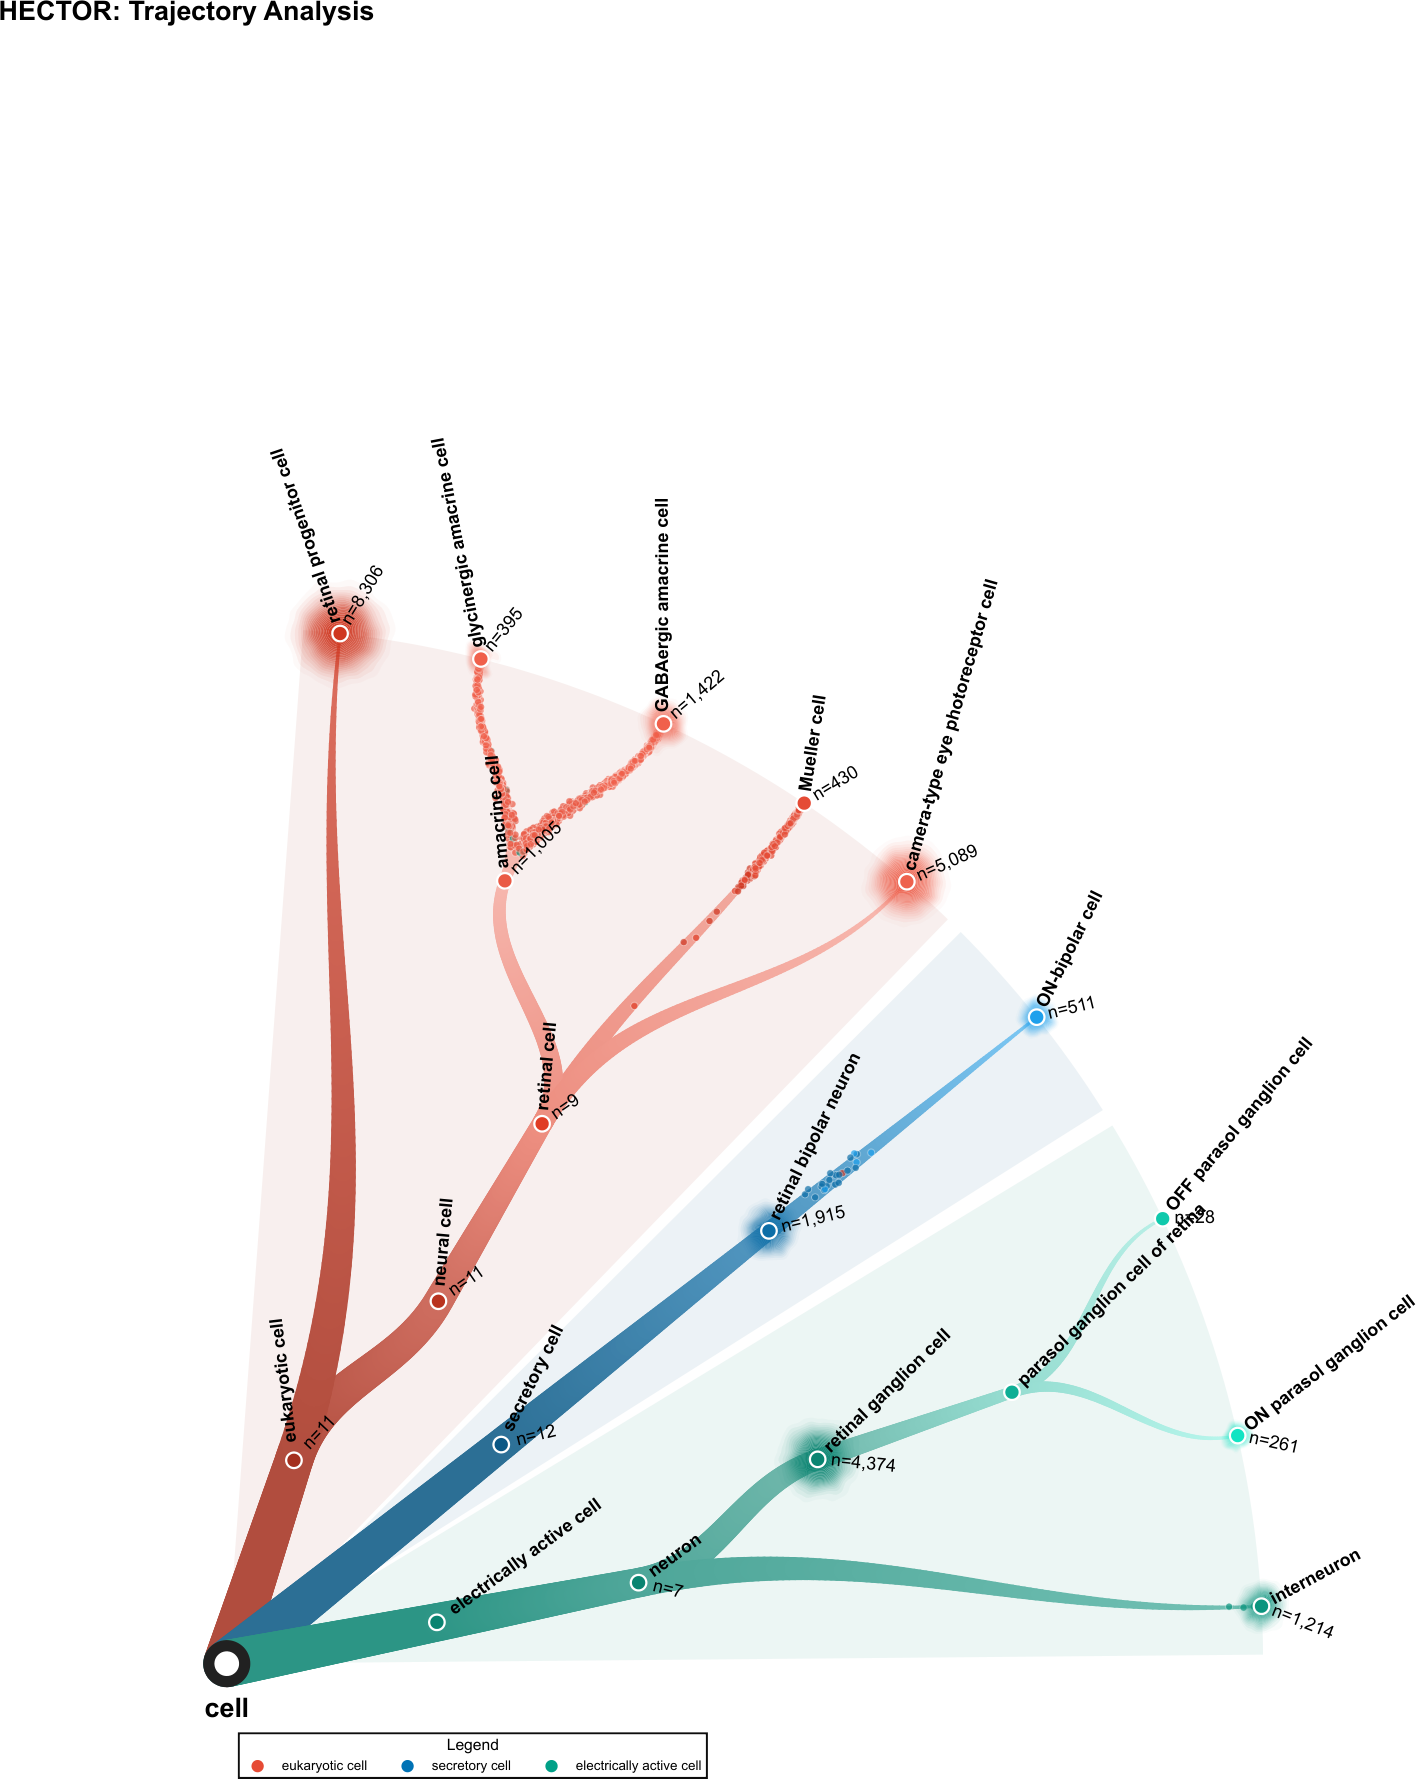

`plot_simplified_tree` is the counterpart to `create_trajectory_analysis` from
tutorial 02: same layouts, same `.pdf` or `.html` choice, but it draws the
simplified groups instead of the original labels.

## Step 5. The threshold is the dial

`similarity_threshold` runs from 0 to 1 and sets how alike two types must be
before they are merged. **Higher keeps more distinctions; lower merges more.**
There is no correct value — it depends on the grain your question needs.

`compute_transitions=False` below skips the per-cell scoring described in
Step 8, which is not needed to count groups and makes each call much faster.

In [8]:
for threshold in (0.90, 0.85, 0.80, 0.70):
    hector.simplify_ontology_tree(
        predictor, adata,
        algorithm="wang",
        similarity_threshold=threshold,
        label_format="name",
        compute_transitions=False,
    )
    groups = adata.obs["simplified_prediction"].value_counts()
    print(f"{threshold:.2f} -> {len(groups):2d} groups | "
          f"largest: {groups.index[0]} ({groups.iloc[0]:,})")

0.90 -> 30 groups | largest: retinal progenitor cell (8,306)


0.85 -> 17 groups | largest: retinal progenitor cell (8,306)


0.80 -> 16 groups | largest: retinal progenitor cell (8,306)
0.70 -> 11 groups | largest: retinal progenitor cell (8,306)


| threshold | groups | what happens |
| --- | --- | --- |
| 0.90 | 30 | the diffuse bipolar subtypes survive as separate labels |
| 0.85 | 17 | families collapse, retina-specific names kept |
| 0.80 | 16 | nearly the same count, different grouping: `glycinergic amacrine cell` joins `amacrine cell` |
| 0.70 | 11 | Müller glia become `radial glial cell` — a term from brain, not eye |

**Watch the names, not just the count**, and stop when they stop being useful.
Below about 0.8 on this data the labels start climbing out of the retina into
general nervous-system terms: `radial glial cell` is correct in the ontology's
sense and useless in a retina figure. The count barely moves between 0.85 and
0.80 while the grouping changes underneath it, so the number of groups on its
own is not a good guide.

## Step 6. The other two algorithms

`wang` is one of three, and it is the one to reach for first. The other two
answer different questions, and each has a habit worth seeing before you spend
time on it.

**`algorithm="level"` rolls up to a fixed depth in the ontology** — everything
deeper than `target_level` is replaced by its ancestor at that depth. Use it
when you want labels that are all the same distance from the root, for instance
to compare against someone else's annotation done at a known grain. It takes no
threshold.

In [9]:
hector.simplify_ontology_tree(
    predictor, adata,
    algorithm="level", target_level=6,
    label_format="name", compute_transitions=False,
)
level_groups = adata.obs["simplified_prediction"].value_counts()
# Nodes kept only to join two groups are counted separately: they are part of the
# tree's shape rather than groups in their own right, so the threshold leaves
# them alone however few cells they hold.
junctions = set(adata.uns["hector_simplified"].get("connector_nodes", []) or [])
small = [name for name, n in level_groups.items()
         if n < 20 and name not in junctions]
print(f"level 6: {len(level_groups)} groups, "
      f"{len(small)} of them with fewer than 20 cells "
      f"({int((level_groups < 20).sum())} counting the junctions)")

level 6: 36 groups, 0 of them with fewer than 20 cells (10 counting the junctions)


Thirty-six groups, and none of them is a cell type holding fewer than twenty
cells. Ten nodes do hold fewer, and every one is a junction the tree needs to
connect the groups on either side of it. Take those away and the tree falls
apart into a row of unconnected nodes.

Rolling up by depth only affects types deeper than the target, so anything
already shallow keeps its own label. Here that means `retinal ganglion cell`
and `amacrine cell` survive alongside the depth-6 groups.

**`algorithm="lineage"` is the default**, and groups types by the shape of the
subtrees they sit in rather than by a similarity score.

In [10]:
hector.simplify_ontology_tree(
    predictor, adata,
    algorithm="lineage",
    label_format="name", compute_transitions=False,
)
adata.obs["simplified_prediction"].value_counts()

simplified_prediction
eukaryotic cell                       9772
camera-type eye photoreceptor cell    5089
retinal ganglion cell                 4663
OFF-bipolar cell                      1512
GABAergic amacrine cell               1422
interneuron                           1214
ON-bipolar cell                        511
retinal bipolar neuron                 403
glycinergic amacrine cell              395
glutamatergic neuron                     8
neuron                                   7
secretory cell                           4
Name: count, dtype: int64

Twelve groups, and the names have left the retina. The largest is
`eukaryotic cell`, holding 9,772 nuclei — two-fifths of the slice under a label
no figure can use. Grouping by subtree shape collapses a whole lineage into its
root, and when one lineage covers most of your cells the root it collapses to
is far too general. `min_group_size` and `max_group_size` are the dials; lower
`max_group_size` for a finer tree.

**`min_cells_number` removes small groups under all three algorithms.** After
merging, any group below that threshold is folded into the nearest node above
it that the tree already draws — either a bigger group, or one of the junctions
that hold the tree together. The label can only get broader, never sideways
into a group the cell does not belong under.

The one thing it will not remove is a junction. Those hold the tree together,
so they stay however few cells they carry, which is why the count above
distinguishes them.

## Step 7. Which to use

| | `wang` | `level` | `lineage` |
| --- | --- | --- | --- |
| grouped by | similarity in the ontology | fixed depth from the root | subtree shape |
| dial | `similarity_threshold` | `target_level` | `min_group_size` / `max_group_size` |
| groups at one depth | no | yes | no |
| absorbs tiny groups | yes | yes | yes |
| watch out for | nothing in particular | shallow types keep their own label | one lineage can swallow the dataset |
| reach for it when | you want readable labels | you need a fixed grain | — |

Start with `wang` at 0.85 and move the threshold until the names read the way
you need. Use `level` when something outside your control fixes the grain.

## Step 8. What it writes

Having settled on a setting, run it once more with the per-cell scoring left
on — it is on by default, and Step 5 turned it off only for speed.

In [11]:
hector.simplify_ontology_tree(
    predictor, adata,
    algorithm="wang", similarity_threshold=0.85,
    label_format="name",
)

adata.obs["simplified_trajectory_state"].value_counts()

simplified_trajectory_state
Stable           22304
Transitioning     2696
Name: count, dtype: int64

Seven columns are written, plus `adata.uns["hector_simplified"]`:

* **`simplified_prediction`** — the new label. This is the one most people
  want.
* **`simplified_trajectory_state`** — `Stable` for a cell sitting on one of the
  simplified groups, `Transitioning` for one placed part of the way along a
  branch between two of them.
* **`simplified_trajectory_source`** and **`simplified_trajectory_target`** —
  the groups at the two ends of that branch.
* **`simplified_relative_position`** — where along the branch the cell
  sits, 0 at the source and 1 at the target, defined for every cell.
* **`simplified_transition_position`** — the same for `Transitioning` cells
  only, rescaled to fill 0 to 1, and 0 elsewhere.
* **`simplified_global_score`** — depth and position in one number: the integer
  part is the depth in the simplified tree, the fraction is the position along
  the branch. Comparable across all cells.

`adata.uns["hector_simplified"]["simplification_map"]` is the lookup from
original label to group, which is what to consult when a group's membership
surprises you. Two more keys sit beside it: `folded_nodes`, listing each group
that fell below `min_cells_number` with where its cells went and how many, and
`connector_nodes`, the junctions kept to hold the tree together.

In [12]:
mapping = adata.uns["hector_simplified"]["simplification_map"]
{k: v for k, v in mapping.items() if "bipolar" in k}

{'diffuse bipolar 2 cell': 'retinal bipolar neuron',
 'flat midget bipolar cell': 'retinal bipolar neuron',
 'diffuse bipolar 3a cell': 'retinal bipolar neuron',
 'retinal bipolar neuron': 'retinal bipolar neuron',
 'diffuse bipolar 3b cell': 'retinal bipolar neuron',
 'OFF-bipolar cell': 'retinal bipolar neuron',
 'diffuse bipolar 1 cell': 'retinal bipolar neuron',
 'invaginating midget bipolar cell': 'ON-bipolar cell',
 'rod bipolar cell': 'ON-bipolar cell',
 'diffuse bipolar 6 cell': 'ON-bipolar cell',
 'ON-bipolar cell': 'ON-bipolar cell',
 'diffuse bipolar 4 cell': 'ON-bipolar cell',
 'ON-blue cone bipolar cell': 'ON-bipolar cell',
 'giant bipolar cell': 'ON-bipolar cell',
 'diffuse bipolar 5 cell': 'ON-bipolar cell',
 'type 3 cone bipolar cell (sensu Mus)': 'retinal bipolar neuron'}

**These positions are not development, and this dataset makes that tempting to
forget.** The branches are the ontology's "is a" relationships — a rod bipolar
cell *is a* retinal bipolar neuron — so a position along one measures how
decisively a cell matched the more specific group, exactly as in tutorial 02. A
developing retina really is building itself over these weeks, but that is not
what these numbers record, and nothing here tracks a cell turning into another
kind of cell.

## Where next

Tutorial 05 ranks the genes the model relies on to recognise each cell type.

Do not feed it this tutorial's output directly. Simplification merges upward,
and nothing stops a group and one of its own subtypes from both surviving —
look again at Step 4's counts, where `amacrine cell` sits alongside
`GABAergic amacrine cell` and `glycinergic amacrine cell`. That is fine for a
figure, where the three are drawn in their own places. It is wrong for marker
ranking, which scores every group against every other and so needs groups that
do not contain one another. Tutorial 05 builds its own.